# Introduction

Tausug people are the native speakers of Bahasa Sug, a low-resource language spoken in the southern Philippines. This exercise applies text preprocessing techniques to a Bahasa Sug book in PDF format. The preprocessing steps are designed with an end goal in mind: developing a simple text generation model while preserving the natural structure of the language.


In [145]:
import pdfplumber
import string
import re
import pandas as pd
import matplotlib.pyplot as plt
import fitz
import pytesseract
import io
import cv2
import numpy as np
import os
import google.genai
import time
import nltk

In [2]:
pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

print(pytesseract.get_tesseract_version())

5.5.0.20241111


In [146]:
from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from PIL import Image
from pytesseract import Output
from google import genai

Although text generation models typically require large corpora for better performance, this demonstration uses only a single PDF book for simplicity and educational purposes.

In [4]:
path = "PDFs/847549027-Tsg-Kata-Kata-Iban-Tarasul-Legends-and-Ballads-1973.pdf"

### Step 1: Extract Text

Pages 1 to 7 and the last page of the PDF are written in English and will therefore be removed from the dataset.

##### Option 1: Simple text extraction using pdfplumber

In [5]:
def extract_text(path, start_page=7):
    text = ""
    
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages[start_page-1:-1]:
            page_text = page.extract_text()
            
            if page_text:
                text += page_text + "\n"
    
    return text

In [6]:
raw_text = extract_text(path)

In [7]:
print(raw_text[:300])

.
I Bahagi Panagnaan
Awn duwa magtiyaun.
Nagbay ha higad kabbun.
In ngan hi Bapl kay Babil.
Mag-usaha lanai matuyu.
Nasusa hi Babo kay Bap‘a.,
Way anak minsan ba.a-bata.
3
Awn hambuuk adlaw naghinang
hi Babu bang-bang.
"Nasusa aku," laung niya, "Way
duun anak ku tumabang.
4y
Mag-unu na kami Bap‘a,
b


##### Option 2: OCR using Tesseract

Upon manual inspection, PDF contains special characters e.g., grave accents, that are not properly extracted by pdfplumber

In [8]:
def extract_text_ocr(path, start_page=7):

    text = ""
    pdf = fitz.open(path)

    #exclude the last page
    for page_num in range(start_page - 1, len(pdf) - 1):

        page = pdf[page_num]

        #render page as image
        pix = page.get_pixmap(dpi=300)
        img = Image.open(io.BytesIO(pix.tobytes("png")))

        #convert PIL image to OpenCV format
        img_cv = np.array(img)

        #convert to grayscale
        gray = cv2.cvtColor(img_cv, cv2.COLOR_RGB2GRAY)

        #apply thresholding
        thresh = cv2.threshold(
            gray,
            150,
            255,
            cv2.THRESH_BINARY
        )[1]

        #perform OCR with confidence scores
        data = pytesseract.image_to_data(
            thresh,
            output_type=Output.DICT
        )

        words = []

        for i in range(len(data["text"])):

            word = data["text"][i].strip()

            try:
                conf = float(data["conf"][i])
            except:
                conf = -1

            #keep only high-confidence text
            if conf > 60 and word:
                words.append(word)

        page_text = " ".join(words)

        #skip pages that are mostly images or noise
        if len(page_text.split()) < 5:
            continue

        text += page_text + "\n"

    pdf.close()

    return text

In [9]:
text_from_ocr = extract_text_ocr(path)

In [10]:
print(text_from_ocr[:300])

1 Bahagi Panagnaan Awn duwa magtiyaun. Nagbay ha higad kabbun. In ngan hi Bapa kay Babu. Mag-usaha Nasusa hi Babu kay Bapa. Way anak minsan
Awn hambuuk naghinang hi Babu bang-bang. "Nasusa aku," niya, "Way duun anak ku tumabang. Mag-unu na kami kay bang wav anak namu dakula? Bang na makaig ha way na


##### Option 3: Use Gemini as the OCR engine for every PDF page

In [33]:
os.environ["GEMINI_API_KEY"] = "REPLACE_API_KEY"

client = genai.Client()

In [45]:
def gemini_ocr_images(images):
    """
    Extract text from one or more PIL images using Gemini.
    """

    prompt = """
    You are an OCR engine.

    Instructions:
    - Extract all readable text exactly as it appears.
    - Ignore logos, decorative elements, images, and signatures.
    - Ignore page numbers if possible.
    - Do not summarize or translate.
    - Preserve line breaks when appropriate.
    - Return only the extracted text.

    If multiple images are provided, separate the output using:

    ----- PAGE 1 -----
    ----- PAGE 2 -----
    ...

    """

    contents = [prompt]

    # Add all images to the request
    for image in images:
        contents.append(image)

    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=contents
    )

    return response.text.strip()

In [46]:
def extract_text_gemini(path, start_page=7, batch_size=50):

    text = ""
    pdf = fitz.open(path)

    end_page = len(pdf) - 1  #exclude last page

    for batch_start in range(start_page - 1, end_page, batch_size):

        images = []

        batch_end = min(batch_start + batch_size, end_page)

        print(
            f"Processing pages "
            f"{batch_start + 1} to {batch_end}..."
        )

        for page_num in range(batch_start, batch_end):

            page = pdf[page_num]

            pix = page.get_pixmap(dpi=300)

            image = Image.open(
                io.BytesIO(
                    pix.tobytes("png")
                )
            )

            images.append(image)

        #one API call
        page_text = gemini_ocr_images(images)

        text += page_text + "\n\n"

        #optional delay to avoid rate limits
        if batch_end < end_page:
            time.sleep(120)

    pdf.close()

    return text

In [47]:
text_from_gemini = extract_text_gemini(path)

Processing pages 7 to 56...
Processing pages 57 to 106...
Processing pages 107 to 156...
Processing pages 157 to 166...


In [49]:
print(text_from_gemini[:500])

----- PAGE 3 -----
1    Bahagi Panagnaan

Awn duwa magtiyaun.
Nagbay ha higad kabbun.
In ngan hi Bapà kay Babù.
Mag-usaha landù matuyù.
Nasusa hi Babù kay Bapà.
Way anak minsan batà-batà.

3

----- PAGE 4 -----
Awn hambuuk adlaw naghinang
hi Babù bang-bang.
"Nasusa aku," laung niya, "Way
duun anak ku tumabang.
Mag-unu na kami kay Bapà,
bang way anak namù dakulà?
Bang di na makaig ha kulangan,
way na minsan maraak maghinang."

4

----- PAGE 5 -----
"Pag-ubus ku addunun in bang-bang
hiluun pa kahà


### Comparing the results of the three options

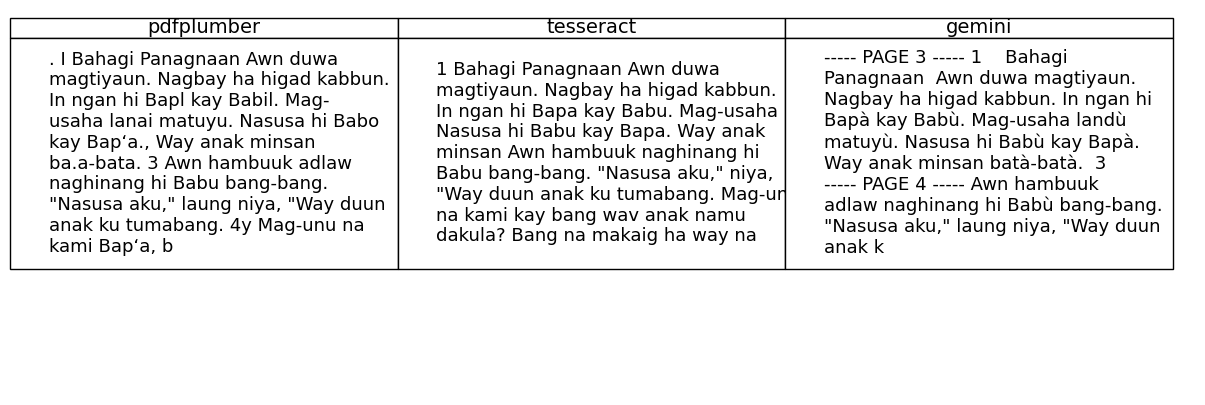

In [147]:
import textwrap

data = [
    [raw_text[:300], text_from_ocr[:300], text_from_gemini[:300]]
]

columns = ["pdfplumber", "tesseract", "gemini"]

table = pd.DataFrame(data, columns=columns)

#wrap text
wrapped_data = table.applymap(
    lambda x: "\n".join(textwrap.wrap(str(x), width=35))
)

#determine the required height based on the longest cell
max_lines = max(
    len(wrapped_data.iloc[0][col].split("\n"))
    for col in wrapped_data.columns
)

fig, ax = plt.subplots(figsize=(15, max(5, max_lines * 0.45)))
ax.axis("off")

tbl = ax.table(
    cellText=wrapped_data.values,
    colLabels=wrapped_data.columns,
    loc="best",
    colWidths=[1/3, 1/3, 1/3]
)

tbl.auto_set_font_size(False)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontsize=14, ha="center", va="center")
    else:
        cell.set_text_props(fontsize=13, ha="left", va="center")
        cell.set_height(max_lines * 0.05)

tbl.scale(1, 1.2)

plt.show()

## Winner!!!

### The results from Gemini are more accurate and complete compared with the other two methods, which have missing text.

### Why Choose LLM?

##### LLMs such as Gemini understand the content of an image or document. Unlike traditional OCR, they can distinguish actual text from logos, decorations, and images, resulting in more accurate and cleaner text extraction, especially for scanned or complex documents.

### Step 2: Clean Text

In [148]:
import unicodedata

def clean_text(text):

    #to lower
    text = text.lower()

    #remove page labels like ----- PAGE 4 -----
    text = re.sub(r'-*\s*page\s*\d+\s*-*', '', text, flags=re.IGNORECASE)

    #remove standalone page numbers
    text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)

    #remove accents (à -> a)
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')

    #remove punctuation except period to keep sentence boundaries
    punctuation = string.punctuation.replace(".", "")
    text = text.translate(str.maketrans("", "", punctuation))

    #remove words that contain numbers
    text = re.sub(r'\w*\d\w*', '', text)

    #substitute multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [149]:
cleaned_text = clean_text(text_from_gemini)

In [150]:
print(cleaned_text[:300])

bahagi panagnaan awn duwa magtiyaun. nagbay ha higad kabbun. in ngan hi bapa kay babu. magusaha landu matuyu. nasusa hi babu kay bapa. way anak minsan batabata. awn hambuuk adlaw naghinang hi babu bangbang. nasusa aku laung niya way duun anak ku tumabang. magunu na kami kay bapa bang way anak namu d


### Step 3: Tokenization

In [156]:
def tokenize(text):
    nltk.download('punkt')
    nltk.download('punkt_tab')
    words  = nltk.word_tokenize(cleaned_text)
    
    return words

In [157]:
tokenized_words = tokenize(cleaned_text)

[nltk_data] Downloading package punkt to C:\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [158]:
print(tokenized_words[:50])

['bahagi', 'panagnaan', 'awn', 'duwa', 'magtiyaun', '.', 'nagbay', 'ha', 'higad', 'kabbun', '.', 'in', 'ngan', 'hi', 'bapa', 'kay', 'babu', '.', 'magusaha', 'landu', 'matuyu', '.', 'nasusa', 'hi', 'babu', 'kay', 'bapa', '.', 'way', 'anak', 'minsan', 'batabata', '.', 'awn', 'hambuuk', 'adlaw', 'naghinang', 'hi', 'babu', 'bangbang', '.', 'nasusa', 'aku', 'laung', 'niya', 'way', 'duun', 'anak', 'ku', 'tumabang']


### Step 4: Stopword Removal

### The link below is the list of common English stopwords translated into Bahasa Sug by Dr. Ahmad Hajiri, a native speaker of the language and a medical doctor by profession.

https://docs.google.com/document/d/1BOkJzLPjuqH9GOn2AnPfHEE0y6mOLLWmHJM8RltX5l0/edit?usp=sharing

In [159]:
#custom bahasa sug stopwords
stopwords = {
    "in", "ing", "ukab", "ha", "pa",
    "ha", "an", "bang", "sin", "hi",
    "iban", "sagawa", "ampa", "atawa",
    "sabab", "sampay", "pasal", "aku",
    "siya", "ini", "yan", "sila", "kaku", 
    "aku", "ku", "kuh"
}

In [160]:
def remove_stopwords(words):
    filtered_words = [
        word for word in words
        if word not in stopwords
    ]
    
    return filtered_words

In [161]:
filtered_words = remove_stopwords(tokenized_words)

print(filtered_words[:50])

['bahagi', 'panagnaan', 'awn', 'duwa', 'magtiyaun', '.', 'nagbay', 'higad', 'kabbun', '.', 'ngan', 'bapa', 'kay', 'babu', '.', 'magusaha', 'landu', 'matuyu', '.', 'nasusa', 'babu', 'kay', 'bapa', '.', 'way', 'anak', 'minsan', 'batabata', '.', 'awn', 'hambuuk', 'adlaw', 'naghinang', 'babu', 'bangbang', '.', 'nasusa', 'laung', 'niya', 'way', 'duun', 'anak', 'tumabang', '.', 'magunu', 'na', 'kami', 'kay', 'bapa', 'way']


### Do not remove stopwords all the time.

Stopword removal is beneficial for tasks such as text classification, keyword extraction, and information retrieval. However, text generation models require all words to learn language patterns and contextual relationships, especially for low-resource language such as Bahasa Sug. Therefore, stopwords will not be removed in this exercise.

### Step 5: Stemming and Lemmatization

Stemming, lemmatization, and spell checking cannot be performed on this dataset because it is written in Bahasa Sug, a low-resource language that currently lacks linguistic rules and lexical databases required for these preprocessing techniques

### Step 6: Word Frequency Analysis

In [162]:
def word_frequency(words):
    return Counter(words)

In [167]:
frequencies = word_frequency(tokenized_words)

### Step 7: Visualization

In [168]:
print("\nTotal Characters:")
print(len(cleaned_text))

print("\nTotal Words:")
print(len(tokenized_words))

print("\nTotal Words After Stopword Removal:")
print(len(filtered_words))


Total Characters:
59674

Total Words:
11483

Total Words After Stopword Removal:
8875


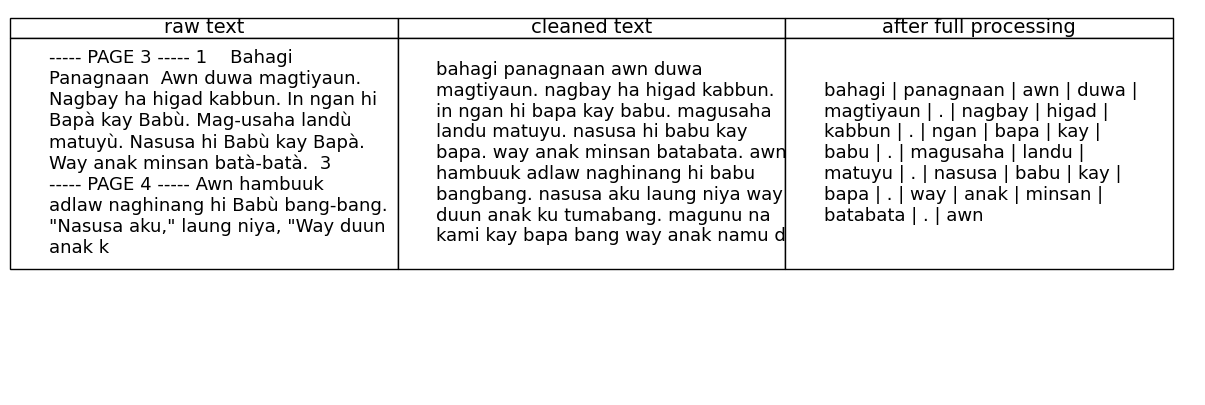

In [169]:
import textwrap

data = [
    [
        text_from_gemini[:300], cleaned_text[:300], " | ".join(filtered_words[:30])
    ]
]

columns = ["raw text", "cleaned text", "after full processing"]

table = pd.DataFrame(data, columns=columns)

#wrap text
wrapped_data = table.applymap(
    lambda x: "\n".join(textwrap.wrap(str(x), width=35))
)

#determine the required height based on the longest cell
max_lines = max(
    len(wrapped_data.iloc[0][col].split("\n"))
    for col in wrapped_data.columns
)

fig, ax = plt.subplots(figsize=(15, max(5, max_lines * 0.45)))
ax.axis("off")

tbl = ax.table(
    cellText=wrapped_data.values,
    colLabels=wrapped_data.columns,
    loc="best",
    colWidths=[1/3, 1/3, 1/3]
)

tbl.auto_set_font_size(False)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontsize=14, ha="center", va="center")
    else:
        cell.set_text_props(fontsize=13, ha="left", va="center")
        cell.set_height(max_lines * 0.05)

tbl.scale(1, 1.2)

plt.show()

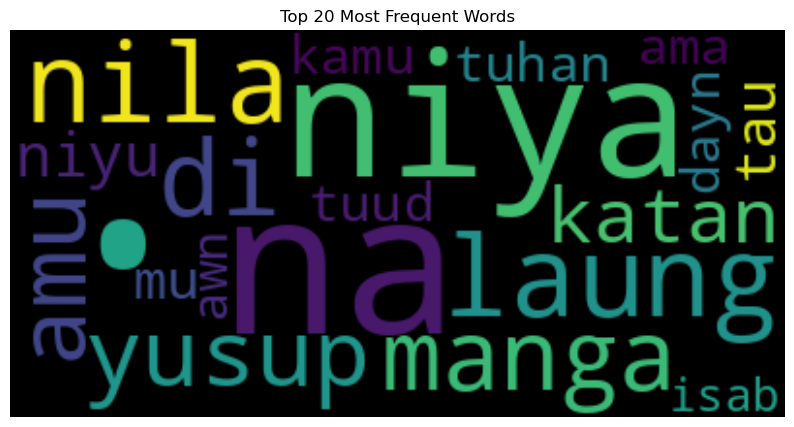

In [170]:
top_words = Counter(filtered_words).most_common(20)

word_freq = dict(top_words)

wordcloud = WordCloud(
    background_color='black'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 10))
plt.title("Top 20 Most Frequent Words")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()